In [2]:
# Setup and Data Initialization
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import gc
import os

print("[*] Loading datasets and spatial infrastructure...")

# 1. File paths
month_file = "includes/flux_gipuzkoa_complet_02-2025.csv"
distritos_path = "includes/gipuzkoa_distritos.shp"
roads_path = "road_gipuzkoa/road_gipuzkoa.shp"
points_path = "points_region_prets.csv"

# 2. Optimized mobility data import (memory management)
df_month = pd.read_csv(
    month_file, 
    usecols=['origen', 'destino', 'viajes', 'fecha'],
    dtype={'origen': 'category', 'destino': 'category', 'viajes': 'float32'}
)

# 3. Geo-data import
gdf_distritos = gpd.read_file(distritos_path)
gdf_gipuzkoa = gdf_distritos[gdf_distritos['ID'].astype(str).str.startswith('20')].copy()
gdf_roads = gpd.read_file(roads_path)
df_p = pd.read_csv(points_path)

# 4. Point calibration (GAMA coordinate alignment)
REF_MIN_X = gdf_distritos.total_bounds[0]
REF_MAX_Y = gdf_distritos.total_bounds[3]
df_p['utm_x'] = df_p['gama_x'] + REF_MIN_X
df_p['utm_y'] = REF_MAX_Y - df_p['gama_y']

gdf_points = gpd.GeoDataFrame(
    df_p, 
    geometry=gpd.points_from_xy(df_p.utm_x, df_p.utm_y), 
    crs="EPSG:25830"
)

# 5. Spatial context plotting function
def roads_and_points(ax, show_roads=True, show_points=True):
    """Overlays road network and POIs for high-visibility mapping."""
    
    # Road network (Black)
    if show_roads:
        gdf_roads.plot(ax=ax, color='black', linewidth=0.45, alpha=0.5, zorder=10)
        
    # POI distribution (Red)
    if show_points:
        gdf_points.plot(ax=ax, color='red', markersize=1.0, alpha=0.2, zorder=11)

print("[+] Setup complete. Assets loaded in memory.")

[*] Loading datasets and spatial infrastructure...
[+] Setup complete. Assets loaded in memory.


Rendering infrastructure layers...


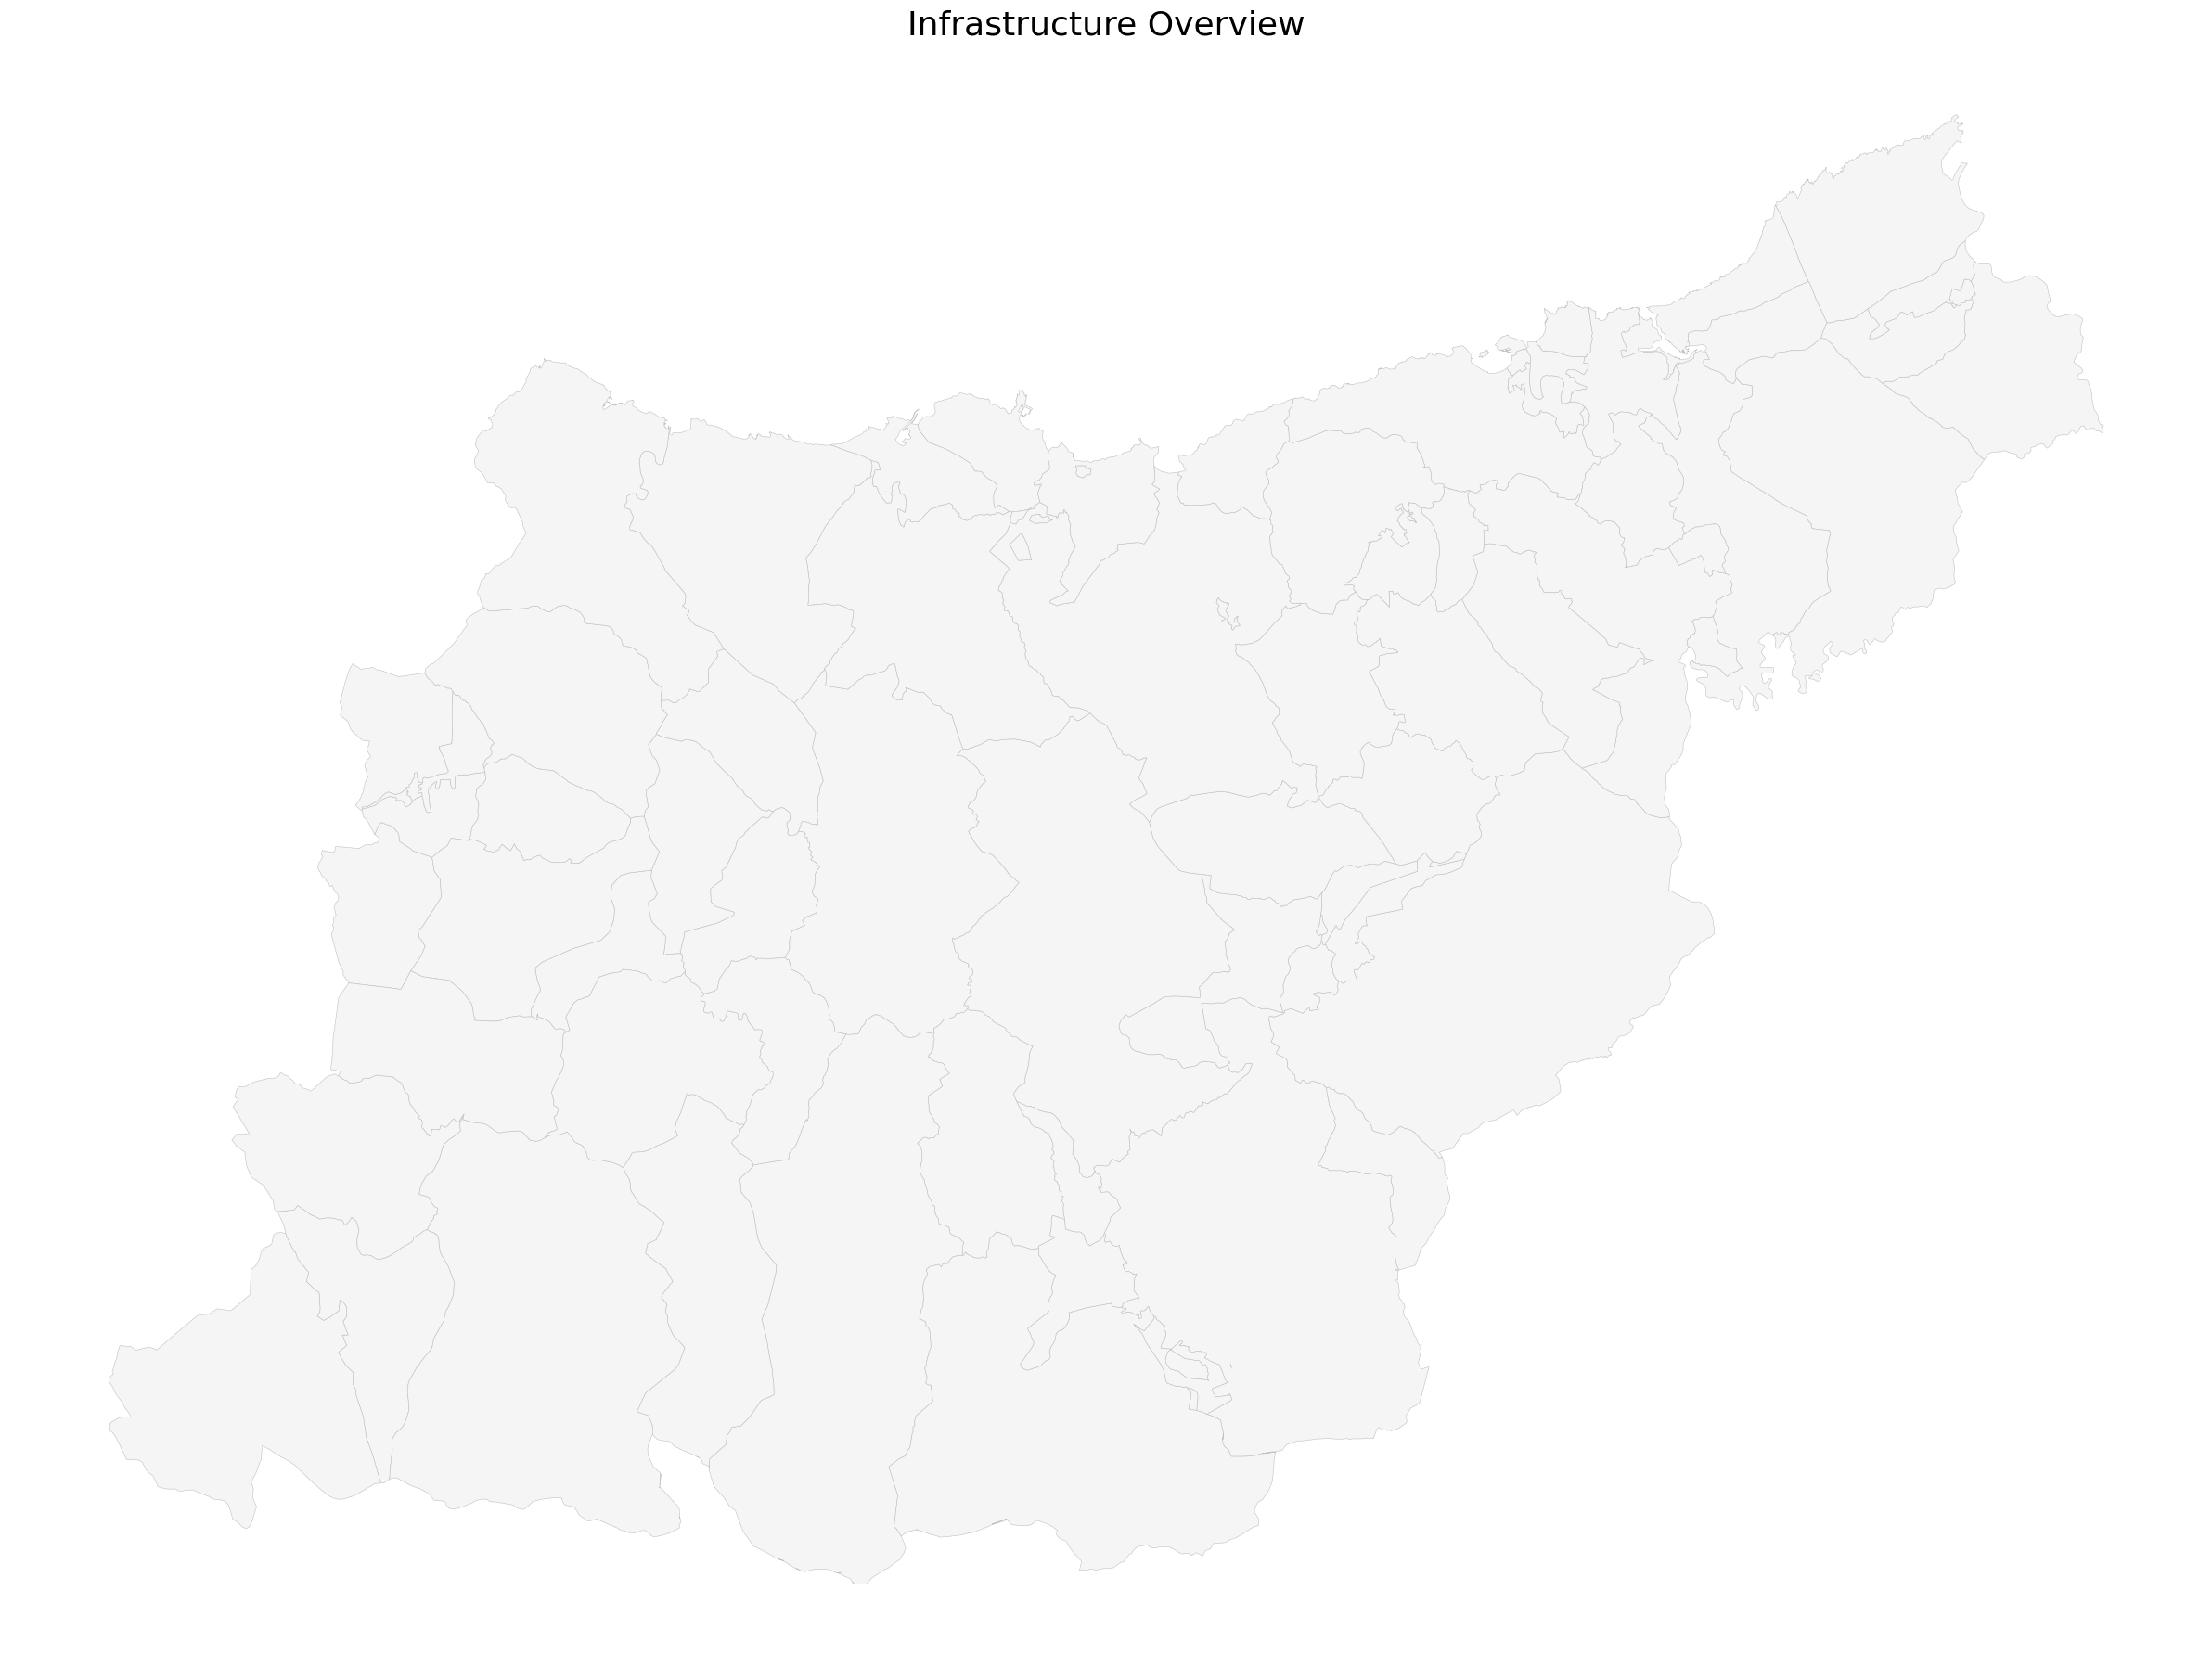

In [3]:
# Infrastructure mapping
print("Rendering infrastructure layers...")

fig, ax = plt.subplots(figsize=(24, 18))

# Background: District boundaries
gdf_gipuzkoa.plot(ax=ax, color='whitesmoke', edgecolor='silver', linewidth=0.4)


ax.set_title("Infrastructure Overview", fontsize=26)
plt.axis('off')

plt.tight_layout()
plt.show()

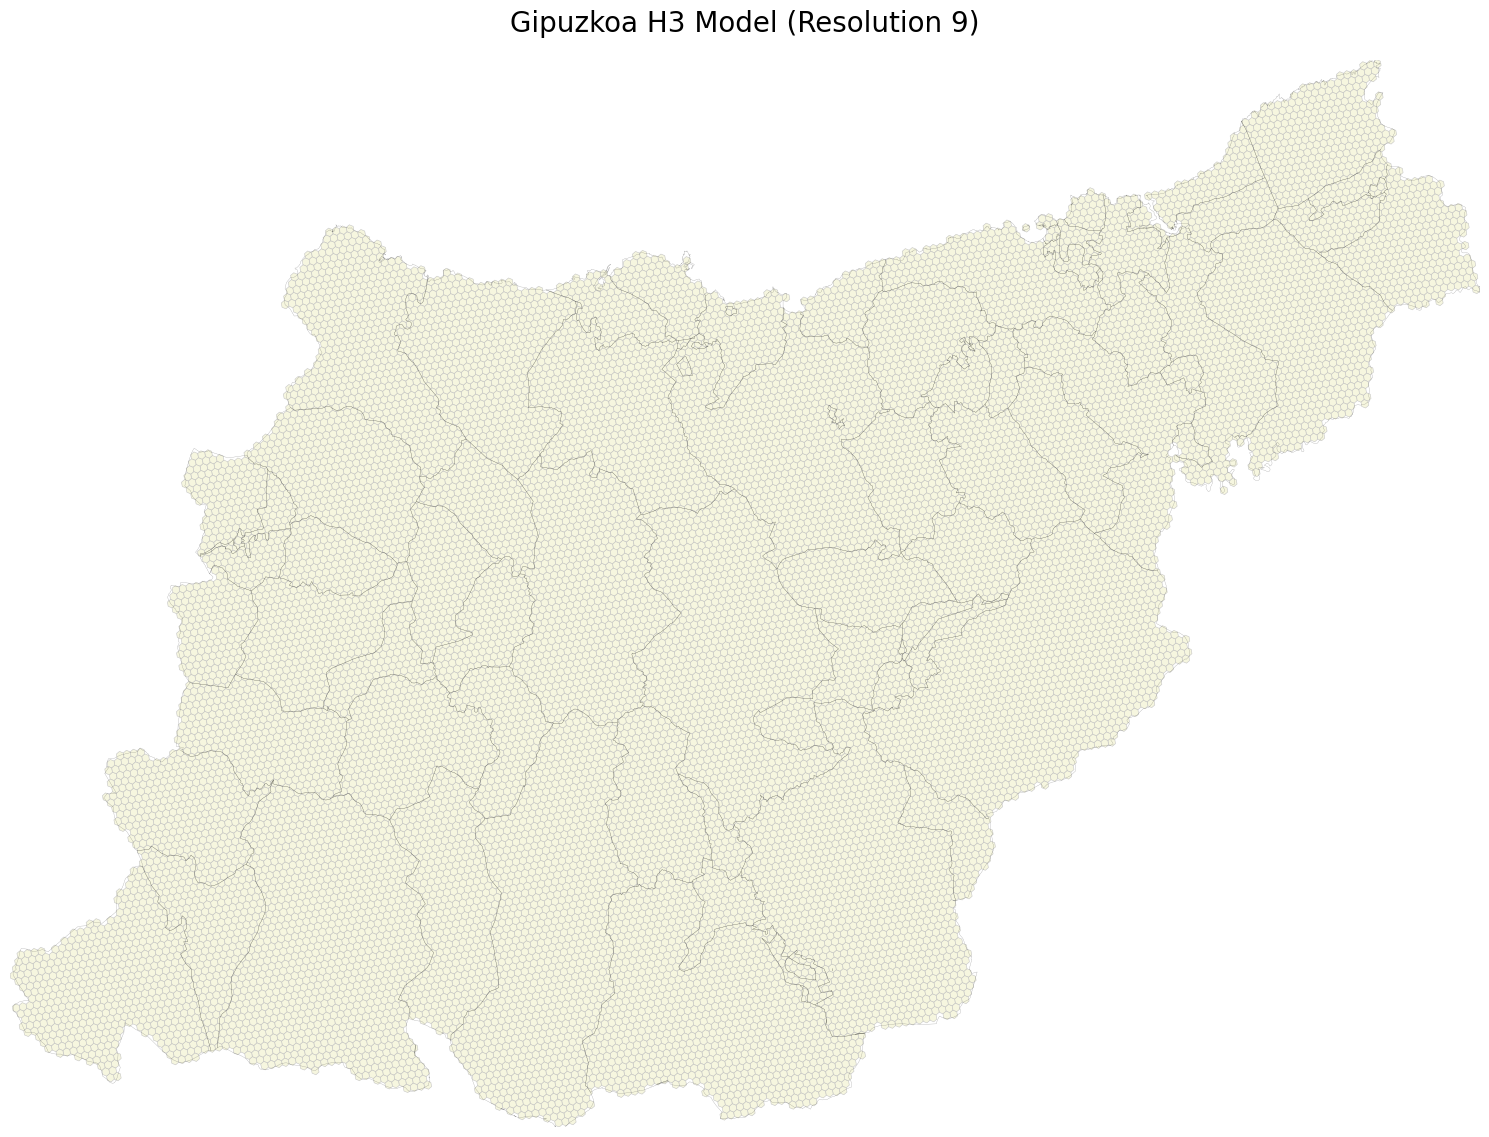

In [4]:
import h3pandas
import matplotlib.pyplot as plt

gdf_h3 = gdf_gipuzkoa.to_crs("EPSG:4326")
hex_gdf = gdf_h3.h3.polyfill(9, explode=True)
hex_gdf = hex_gdf.dropna(subset=['h3_polyfill'])
hex_gdf = hex_gdf.set_index('h3_polyfill').h3.h3_to_geo_boundary()

fig, ax = plt.subplots(figsize=(15, 12))

hex_gdf.plot(
    ax=ax,
    color='#F5F5DC',
    edgecolor='silver',
    linewidth=0.4,
    alpha=0.9
)

gdf_gipuzkoa.to_crs("EPSG:4326").boundary.plot(ax=ax, color='black', linewidth=0.2, alpha=0.4)

ax.set_title("Gipuzkoa H3 Model (Resolution 9)", fontsize=20, pad=20)
ax.set_axis_off()

minx, miny, maxx, maxy = hex_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

plt.tight_layout()
plt.show()


Top 10 Districts by POI Count:
- Donostia/San Sebastián distrito 06: 11353 POIs
- Donostia/San Sebastián distrito 07: 3378 POIs
- Irun distrito 04: 2907 POIs
- Donostia/San Sebastián distrito 04: 2305 POIs
- Errenteria: 2183 POIs
- Hernani: 1942 POIs
- Zarautz distrito 02: 1792 POIs
- Tolosa distrito 03: 1532 POIs
- Oiartzun: 1477 POIs
- Donostia/San Sebastián distrito 02: 1466 POIs


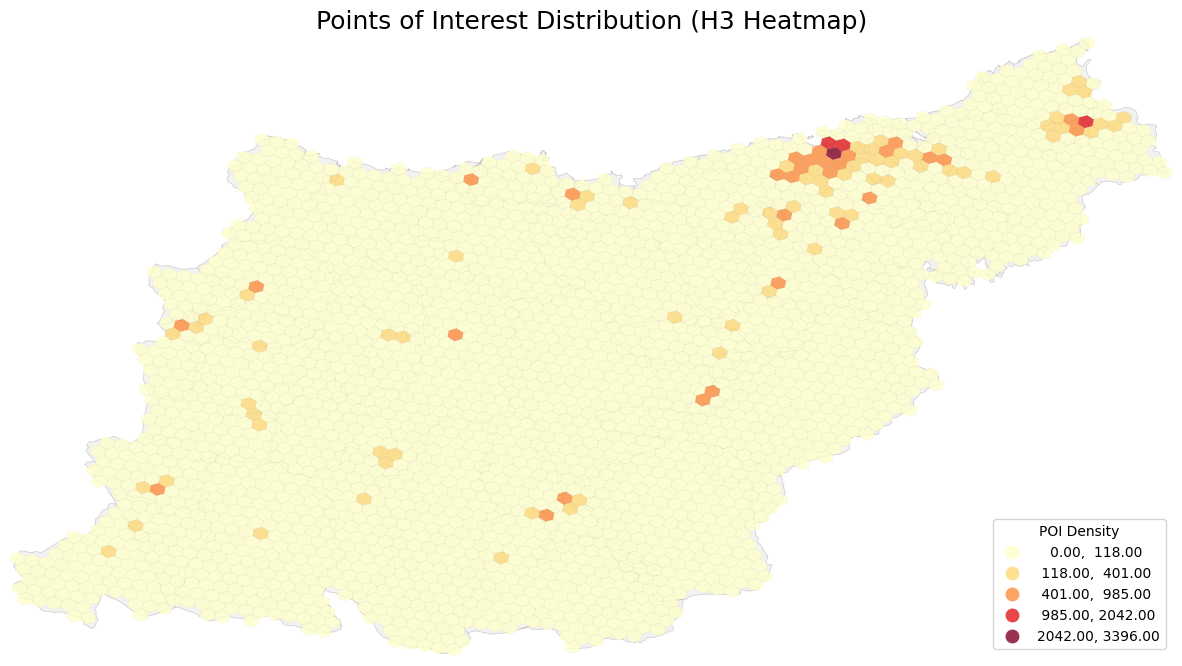

In [7]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import h3pandas
import gc

gdf_h3_base = gdf_gipuzkoa.to_crs("EPSG:4326")
hex_gdf = gdf_h3_base.h3.polyfill(8, explode=True).dropna(subset=['h3_polyfill'])
hex_gdf = hex_gdf.set_index('h3_polyfill').h3.h3_to_geo_boundary()
hex_gdf_clean = hex_gdf.reset_index()


df_fixes = pd.read_csv("points_fixes.csv")
gdf_p = gpd.GeoDataFrame(
    df_fixes, 
    geometry=gpd.points_from_xy(df_fixes.lng, df_fixes.lat), 
    crs="EPSG:4326"
)


points_in_hex = gpd.sjoin(gdf_p, hex_gdf_clean, how="inner", predicate="within")
hex_gdf_clean['poi_count'] = 0

if not points_in_hex.empty:
    counts = points_in_hex.groupby('index_right').size()
    hex_gdf_clean.loc[counts.index, 'poi_count'] = counts.values


fig, ax = plt.subplots(figsize=(15, 12))

gdf_gipuzkoa.to_crs("EPSG:4326").plot(ax=ax, color='#F2F2F2', edgecolor='#CCCCCC', linewidth=0.5)

hex_gdf_clean.plot(
    column='poi_count',
    cmap='YlOrRd',
    scheme='NaturalBreaks',
    k=5,
    legend=True,
    ax=ax,
    edgecolor='black',
    linewidth=0.02,
    alpha=0.8,
    legend_kwds={'title': "POI Density", 'loc': 'lower right'}
)

roads_and_points(ax)

ax.set_title("Points of Interest Distribution (H3 Heatmap)", fontsize=18)
ax.set_axis_off()

minx, miny, maxx, maxy = hex_gdf_clean.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

print("\nTop 10 Districts by POI Count:")

try:
    names_df = pd.read_csv('nombres_distritos.csv', sep='|')
except FileNotFoundError:
    names_df = pd.read_csv(r'zonificacion_distritos\nombres_distritos.csv', sep='|')

names_df['ID'] = names_df['ID'].astype(str)

district_counts = points_in_hex.groupby('ID').size().reset_index(name='total_poi')
district_counts['ID'] = district_counts['ID'].astype(str)

top_10 = district_counts.sort_values(by='total_poi', ascending=False).head(10)
top_10 = top_10.merge(names_df, on='ID', how='left')

for _, row in top_10.iterrows():
    district_name = row['name'] if pd.notnull(row['name']) else f"District {row['ID']}"
    print(f"- {district_name}: {int(row['total_poi'])} POIs")

plt.show()